In [ ]:
# ============================================================
# AI활용실습 (Python 기반) - 4주차 실습
# 주제: 데이터 시각화 + 데이터 전처리 + Text Embedding
# 날짜: 2026년 3월 24일 ~ 30일
# ============================================================

# 4주차: 데이터 시각화 + 데이터 전처리 + Text Embedding

## 목차
- **Part 1.** Matplotlib 기초
- **Part 2.** Seaborn 통계 시각화
- **Part 3.** 정규화 & 표준화 (Normalization & Standardization)
- **Part 4.** 범주형 인코딩 (Label Encoding / One-Hot Encoding)
- **Part 5.** Text Embedding 실습
- **Part 6.** 종합 시각화

---
## ✅ 환경 설정 및 라이브러리 임포트

In [ ]:
!pip install  matplotlib seaborn scikit-learn gensim sentence-transformers 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    matplotlib.rc('font', family='NanumGothic')

matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Matplotlib {matplotlib.__version__}")

✅ 라이브러리 임포트 완료
NumPy 2.4.3 | Pandas 3.0.1 | Matplotlib 3.10.8


ERROR: Invalid requirement: '#matplotlib'

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 📊 Part 1. Matplotlib 기초

### 1-1. Figure / Axes 구조 이해

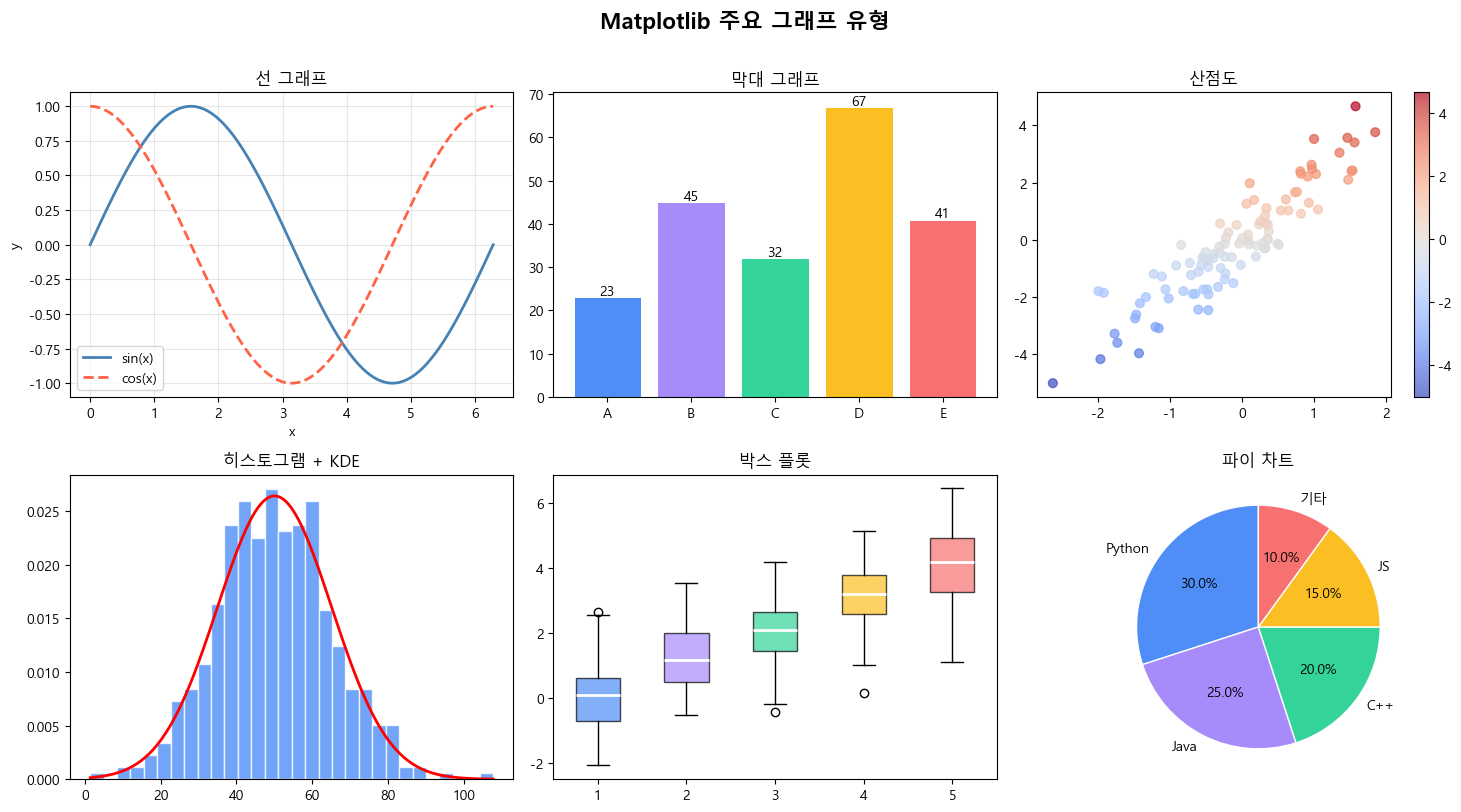

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Matplotlib 주요 그래프 유형', fontsize=16, fontweight='bold', y=1.01)

x = np.linspace(0, 2 * np.pi, 100)
np.random.seed(42)
colors = ['#4f8ef7', '#a78bfa', '#34d399', '#fbbf24', '#f87171']

# 1) 선 그래프
axes[0, 0].plot(x, np.sin(x), label='sin(x)', color='steelblue', linewidth=2)
axes[0, 0].plot(x, np.cos(x), label='cos(x)', color='tomato', linewidth=2, linestyle='--')
axes[0, 0].set_title('선 그래프')
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2) 막대 그래프
cats = ['A', 'B', 'C', 'D', 'E']
vals = [23, 45, 32, 67, 41]
axes[0, 1].bar(cats, vals, color=colors, edgecolor='white', linewidth=0.7)
axes[0, 1].set_title('막대 그래프')
for i, v in enumerate(vals):
    axes[0, 1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# 3) 산점도
x_s = np.random.randn(100)
y_s = 2 * x_s + np.random.randn(100) * 0.8
sc = axes[0, 2].scatter(x_s, y_s, c=y_s, cmap='coolwarm', alpha=0.7, s=40)
axes[0, 2].set_title('산점도')
fig.colorbar(sc, ax=axes[0, 2])

# 4) 히스토그램 + KDE
data = np.random.normal(50, 15, 500)
axes[1, 0].hist(data, bins=30, color='#4f8ef7', edgecolor='white', alpha=0.8, density=True)
from scipy.stats import norm
x_kde = np.linspace(data.min(), data.max(), 200)
axes[1, 0].plot(x_kde, norm.pdf(x_kde, data.mean(), data.std()), 'r-', lw=2)
axes[1, 0].set_title('히스토그램 + KDE')

# 5) 박스 플롯
data_box = [np.random.normal(loc, 1, 100) for loc in range(5)]
bp = axes[1, 1].boxplot(data_box, patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1, 1].set_title('박스 플롯')

# 6) 파이 차트
sizes = [30, 25, 20, 15, 10]
labels = ['Python', 'Java', 'C++', 'JS', '기타']
axes[1, 2].pie(sizes, labels=labels, autopct='%1.1f%%',
               startangle=90, colors=colors,
               wedgeprops=dict(edgecolor='white'))
axes[1, 2].set_title('파이 차트')

plt.tight_layout()
plt.savefig('1_matplotlib_basics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎨 Part 2. Seaborn 통계 시각화

### 2-1. 타이타닉 데이터 로드

In [11]:
titanic = sns.load_dataset('titanic')
print("shape:", titanic.shape)
print("\n결측치:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])
titanic[['survived', 'pclass', 'age', 'fare']].describe().round(2)

shape: (891, 15)

결측치:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


,survived,pclass,age,fare
count,891.00,891.00,714.00,891.00
mean,0.38,2.31,29.70,32.20
std,0.49,0.84,14.53,49.69
min,0.00,1.00,0.42,0.00
25%,0.00,2.00,20.12,7.91
50%,0.00,3.00,28.00,14.45
75%,1.00,3.00,38.00,31.00
max,1.00,3.00,80.00,512.33


### 2-2. 생존율 분석 시각화

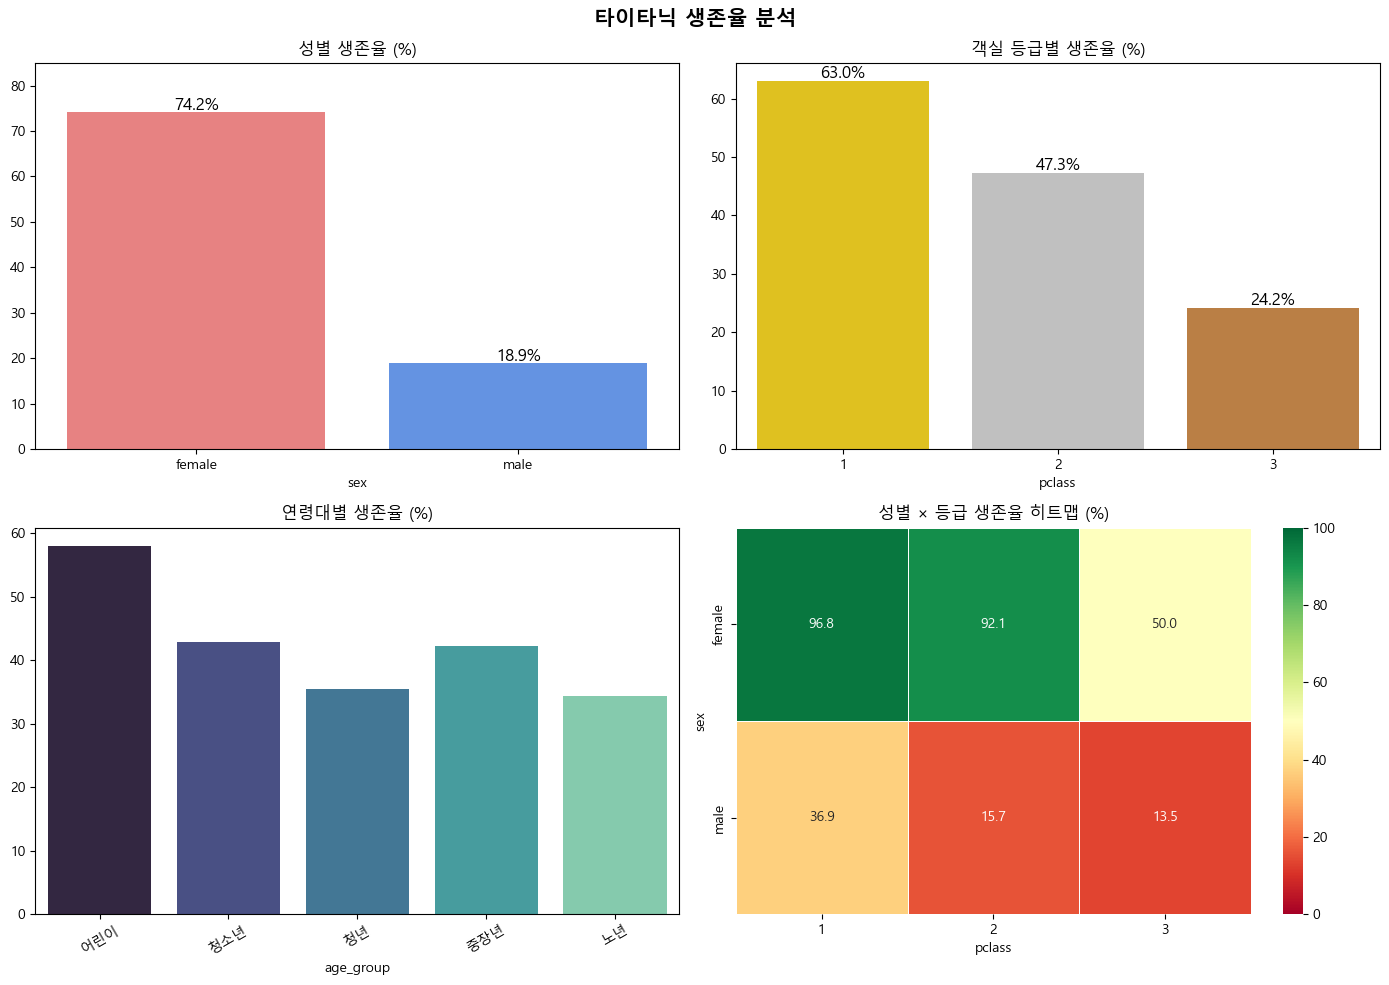

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('타이타닉 생존율 분석', fontsize=15, fontweight='bold')

# 성별 생존율
sur_sex = titanic.groupby('sex')['survived'].mean() * 100
sns.barplot(x=sur_sex.index, y=sur_sex.values,
            palette=['#f87171', '#4f8ef7'], ax=axes[0, 0])
axes[0, 0].set_title('성별 생존율 (%)')
for i, v in enumerate(sur_sex.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)
axes[0, 0].set_ylim(0, 85)

# 객실 등급별 생존율
sur_cls = titanic.groupby('pclass')['survived'].mean() * 100
sns.barplot(x=sur_cls.index, y=sur_cls.values,
            palette=['gold', 'silver', '#cd7f32'], ax=axes[0, 1])
axes[0, 1].set_title('객실 등급별 생존율 (%)')
for i, v in enumerate(sur_cls.values):
    axes[0, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

# 연령대별 생존율
titanic['age_group'] = pd.cut(titanic['age'],
    bins=[0, 12, 18, 30, 50, 100],
    labels=['어린이', '청소년', '청년', '중장년', '노년'])
sur_age = titanic.groupby('age_group', observed=False)['survived'].mean() * 100
sns.barplot(x=sur_age.index, y=sur_age.values, palette='mako', ax=axes[1, 0])
axes[1, 0].set_title('연령대별 생존율 (%)')
axes[1, 0].tick_params(axis='x', rotation=30)

# 성별 × 등급 히트맵
hm = titanic.pivot_table(
    values='survived', index='sex', columns='pclass', aggfunc='mean') * 100
sns.heatmap(hm, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('성별 × 등급 생존율 히트맵 (%)')

plt.tight_layout()
plt.savefig('2_titanic_survival.png', dpi=150, bbox_inches='tight')
plt.show()

### 2-3. 상관관계 히트맵

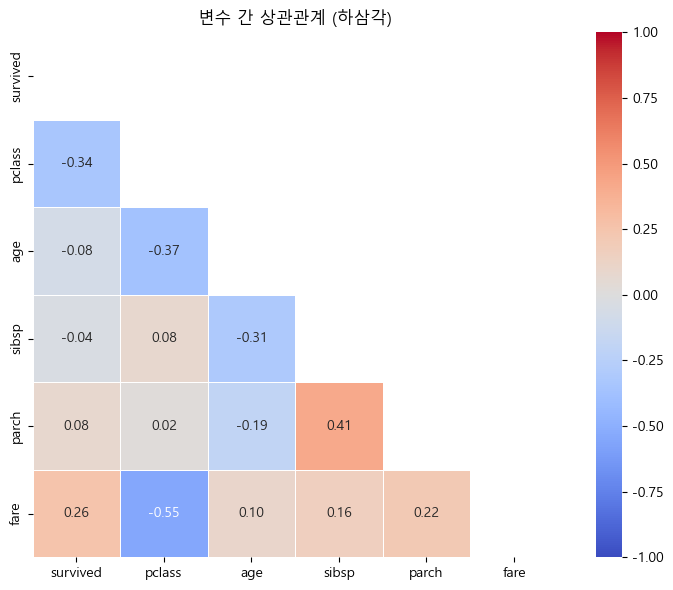

In [13]:
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = titanic[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('변수 간 상관관계 (하삼각)')
plt.tight_layout()
plt.savefig('3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📐 Part 3. 정규화 & 표준화

### 3-1. 개념 확인 — 수식 구현

In [14]:
data_raw = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 200.0])  # 이상치 포함

# ── 직접 구현 ──────────────────────────────────────
# Min-Max 정규화
def min_max_normalize(x):
    return (x - x.min()) / (x.max() - x.min())

# Z-score 표준화
def z_score_standardize(x):
    return (x - x.mean()) / x.std()

mm  = min_max_normalize(data_raw)
std = z_score_standardize(data_raw)

df_compare = pd.DataFrame({
    '원본': data_raw,
    'Min-Max 정규화': mm.round(3),
    'Z-score 표준화': std.round(3),
})
print(df_compare.to_string(index=False))
print(f"\nMin-Max 범위: [{mm.min():.2f}, {mm.max():.2f}]")
print(f"Z-score  평균: {std.mean():.4f}, 표준편차: {std.std():.4f}")

   원본  Min-Max 정규화  Z-score 표준화
 10.0        0.000       -0.748
 20.0        0.053       -0.593
 30.0        0.105       -0.438
 40.0        0.158       -0.284
 50.0        0.211       -0.129
200.0        1.000        2.191

Min-Max 범위: [0.00, 1.00]
Z-score  평균: 0.0000, 표준편차: 1.0000


### 3-2. sklearn으로 구현

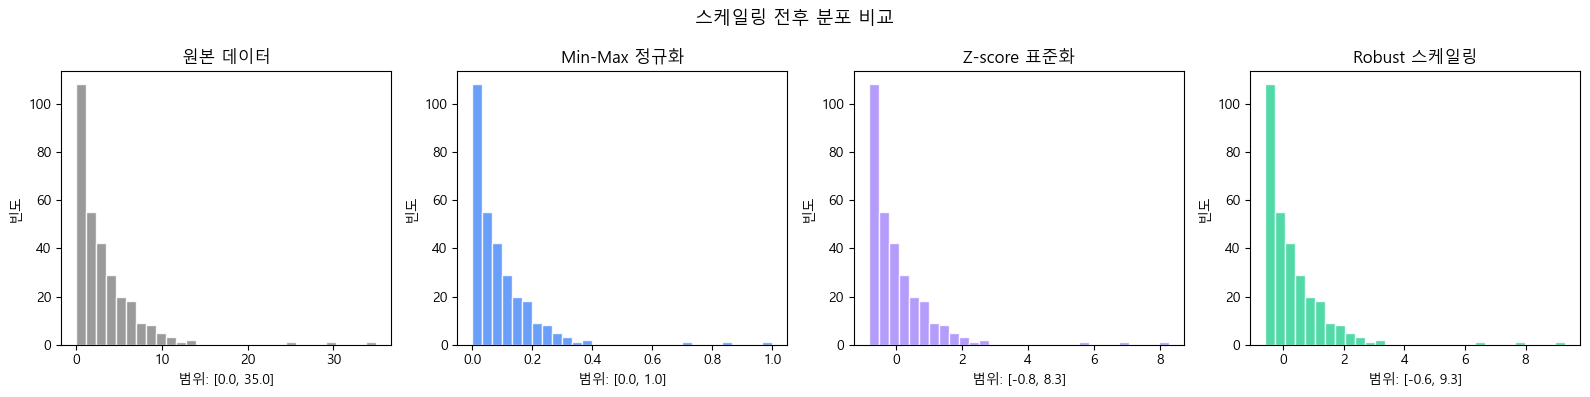

In [15]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

np.random.seed(42)
# 지수 분포 데이터 (오른쪽 꼬리 — 이상치 존재)
X_raw = np.random.exponential(scale=3, size=(300, 1))
# 이상치 몇 개 추가
X_raw = np.append(X_raw, [[25], [30], [35]], axis=0)

X_mm  = MinMaxScaler().fit_transform(X_raw)
X_std = StandardScaler().fit_transform(X_raw)
X_rob = RobustScaler().fit_transform(X_raw)   # 이상치에 강건한 스케일러

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('스케일링 전후 분포 비교', fontsize=13)

for ax, d, title, color in zip(
    axes,
    [X_raw, X_mm, X_std, X_rob],
    ['원본 데이터', 'Min-Max 정규화', 'Z-score 표준화', 'Robust 스케일링'],
    ['#888', '#4f8ef7', '#a78bfa', '#34d399']
):
    ax.hist(d, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(f'범위: [{d.min():.1f}, {d.max():.1f}]')
    ax.set_ylabel('빈도')

plt.tight_layout()
plt.savefig('4_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3-3. 실전 포인트 — train/test 분리 후 스케일링

In [47]:
from sklearn.model_selection import train_test_split

X = np.random.randn(200, 3) * [10, 100, 0.5]  # 스케일이 다른 3개 특징
y = np.random.randint(0, 2, 200)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)       # transform만! (fit 금지)

print("훈련 데이터 스케일링 후:")
print(f"  평균: {X_train_scaled.mean(axis=0).round(4)}")
print(f"  표준편차: {X_train_scaled.std(axis=0).round(4)}")
print("\n⚠️ 테스트 데이터는 transform()만 사용 (훈련 통계 그대로 적용)")
print(f"  테스트 평균: {X_test_scaled.mean(axis=0).round(4)}")

훈련 데이터 스케일링 후:
  평균: [0. 0. 0.]
  표준편차: [1. 1. 1.]

⚠️ 테스트 데이터는 transform()만 사용 (훈련 통계 그대로 적용)
  테스트 평균: [-0.4058 -0.0462 -0.1436]


---
## 🏷️ Part 4. 범주형 데이터 인코딩

### 4-1. Label Encoding

In [49]:
from sklearn.preprocessing import LabelEncoder

# ── 순서 없는 범주 (Label Encoding 주의 필요) ──────────────
colors = ['빨강', '파랑', '초록', '빨강', '파랑', '초록', '빨강']

le = LabelEncoder()
encoded = le.fit_transform(colors)

print("=== Label Encoding ===")
print(f"클래스: {le.classes_}")
print(f"원본:   {colors}")
print(f"인코딩: {encoded}")
print(f"역변환: {list(le.inverse_transform(encoded))}")

# ── 순서 있는 범주 (pandas map 활용) ───────────────────────
df_grade = pd.DataFrame({
    'name':  ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'grade': ['A', 'C', 'B', 'F', 'A'],
})

grade_map = {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}
df_grade['grade_enc'] = df_grade['grade'].map(grade_map)

print("\n=== 순서 있는 범주 — pandas map ===")
print(df_grade)

=== Label Encoding ===
클래스: ['빨강' '초록' '파랑']
원본:   ['빨강', '파랑', '초록', '빨강', '파랑', '초록', '빨강']
인코딩: [0 2 1 0 2 1 0]
역변환: [np.str_('빨강'), np.str_('파랑'), np.str_('초록'), np.str_('빨강'), np.str_('파랑'), np.str_('초록'), np.str_('빨강')]

=== 순서 있는 범주 — pandas map ===
    name grade  grade_enc
0  Alice     A          4
1    Bob     C          2
2  Carol     B          3
3   Dave     F          0
4    Eve     A          4


### 4-2. One-Hot Encoding

In [50]:
# ── pandas get_dummies ──────────────────────────────────────
df_items = pd.DataFrame({
    'color': ['빨강', '파랑', '초록', '빨강', '파랑'],
    'size':  ['S', 'M', 'L', 'M', 'S'],
    'price': [10, 20, 15, 12, 18]
})

print("=== 원본 데이터 ===")
print(df_items)

# drop_first=True: 더미 함정(다중공선성) 방지
ohe_df = pd.get_dummies(
    df_items,
    columns=['color', 'size'],
    drop_first=True,
    dtype=int
)
print("\n=== One-Hot Encoding 결과 (drop_first=True) ===")
print(ohe_df)

=== 원본 데이터 ===
  color size  price
0    빨강    S     10
1    파랑    M     20
2    초록    L     15
3    빨강    M     12
4    파랑    S     18

=== One-Hot Encoding 결과 (drop_first=True) ===
   price  color_초록  color_파랑  size_M  size_S
0     10         0         0       0       1
1     20         0         1       1       0
2     15         1         0       0       0
3     12         0         0       1       0
4     18         0         1       0       1


In [19]:
# ── sklearn OneHotEncoder ───────────────────────────────────
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(drop='first', sparse_output=False)
result = enc.fit_transform(df_items[['color', 'size']])

print("=== sklearn OneHotEncoder 결과 ===")
print("특징 이름:", enc.get_feature_names_out(['color', 'size']))
print(result)

=== sklearn OneHotEncoder 결과 ===
특징 이름: ['color_초록' 'color_파랑' 'size_M' 'size_S']
[[0. 0. 0. 1.]
 [0. 1. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 1.]]


### 4-3. 인코딩 비교 시각화

In [51]:
# 타이타닉 실전 인코딩 파이프라인
titanic_enc = titanic[['sex', 'embarked', 'pclass', 'survived']].dropna().copy()

print("=== 원본 ===")
print(titanic_enc.head())

# Label Encoding: pclass (순서: 1등석 > 2등석 > 3등석 → 역순 매핑)
titanic_enc['pclass_enc'] = titanic_enc['pclass'].map({1: 2, 2: 1, 3: 0})

# One-Hot Encoding: sex, embarked (순서 없는 범주)
titanic_enc = pd.get_dummies(
    titanic_enc,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int
)

print("\n=== 인코딩 후 ===")
print(titanic_enc.head())
print("\n컬럼:", list(titanic_enc.columns))

=== 원본 ===
      sex embarked  pclass  survived
0    male        S       3         0
1  female        C       1         1
2  female        S       3         1
3  female        S       1         1
4    male        S       3         0

=== 인코딩 후 ===
   pclass  survived  pclass_enc  sex_male  embarked_Q  embarked_S
0       3         0           0         1           0           1
1       1         1           2         0           0           0
2       3         1           0         0           0           1
3       1         1           2         0           0           1
4       3         0           0         1           0           1

컬럼: ['pclass', 'survived', 'pclass_enc', 'sex_male', 'embarked_Q', 'embarked_S']


### 4-4. 인코딩 전후 상관관계 변화 확인

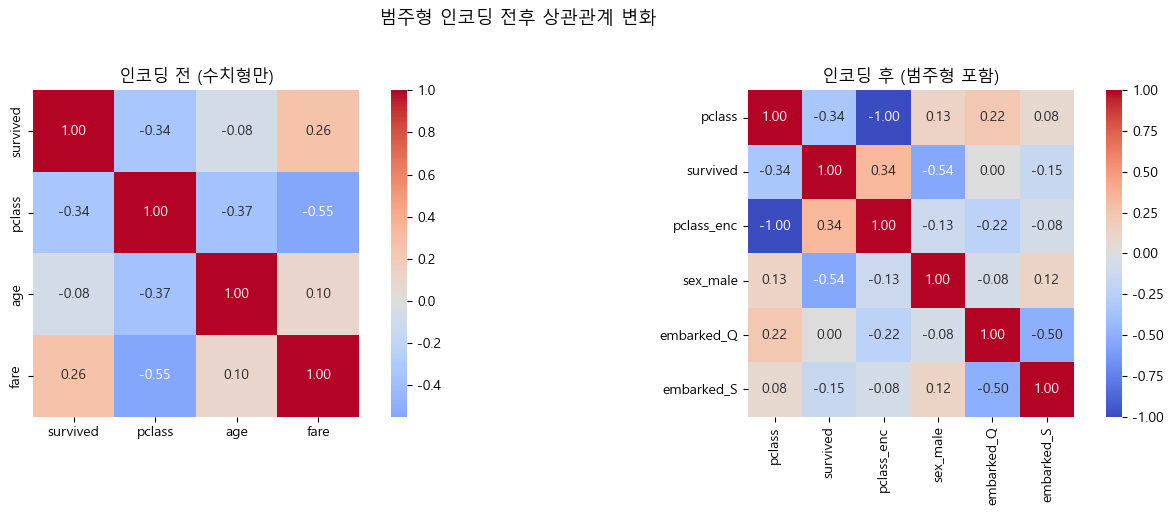

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 인코딩 전 (숫자형만)
corr_before = titanic[['survived', 'pclass', 'age', 'fare']].corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0])
axes[0].set_title('인코딩 전 (수치형만)')

# 인코딩 후
corr_after = titanic_enc.corr()
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1])
axes[1].set_title('인코딩 후 (범주형 포함)')

plt.suptitle('범주형 인코딩 전후 상관관계 변화', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('5_encoding_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 Part 5. Text Embedding 실습

### 5-1. Word2Vec 학습 및 유사도

In [52]:
from gensim.models import Word2Vec

corpus = [
    "강아지는 귀여운 동물이다",
    "고양이도 귀여운 반려동물이다",
    "강아지와 고양이는 인기 있는 반려동물이다",
    "사자와 호랑이는 맹수이다",
    "파이썬은 AI 프로그래밍 언어이다",
    "딥러닝과 머신러닝은 AI 기술이다",
    "신경망은 딥러닝의 핵심 구조이다",
    "자연어처리는 텍스트를 분석하는 AI 기술이다",
    "서울은 대한민국의 수도이다",
    "부산은 한국의 항구 도시이다",
    "야구는 인기 있는 스포츠이다",
    "축구와 야구는 팀 스포츠이다",
    "사과와 바나나는 과일이다",
    "당근과 오이는 채소이다",
]

# 간단 전처리 (공백 분리)
remove_chars = ['은', '는', '이다', '와', '과', '도', '의', '에']
tokenized = []
for sent in corpus:
    for ch in remove_chars:
        sent = sent.replace(ch, ' ')
    tokenized.append(sent.split())

w2v = Word2Vec(
    sentences=tokenized,
    vector_size=64,
    window=3,
    min_count=1,
    sg=1,          # Skip-gram
    seed=42,
    epochs=100
)

print(f"✅ Word2Vec 학습 완료 | 어휘: {len(w2v.wv.key_to_index)}개 단어")

for word in ['강아지', '파이썬', '서울']:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=3)
        print(f"\n'{word}' 유사 단어:")
        for w, s in similar:
            print(f"  {w:10s} {s:.3f}")

✅ Word2Vec 학습 완료 | 어휘: 40개 단어

'강아지' 유사 단어:
  한국         0.242
  분석하        0.202
  고양이        0.202

'파이썬' 유사 단어:
  바나나        0.319
  축구         0.260
  맹수         0.177

'서울' 유사 단어:
  수          0.314
  사자         0.289
  스포츠        0.235


### 5-2. Word2Vec t-SNE 시각화

In [ ]:
from sklearn.manifold import TSNE

words   = list(w2v.wv.key_to_index.keys())
vectors = np.array([w2v.wv[w] for w in words])

tsne = TSNE(n_components=2, perplexity=5, random_state=42,
            n_iter=1000, learning_rate='auto', init='pca')
reduced = tsne.fit_transform(vectors)

category_map = {
    '동물':  ['강아지', '고양이', '사자', '호랑이', '반려동물'],
    'IT/AI': ['파이썬', '딥러닝', '머신러닝', '신경망', 'AI', '자연어처리'],
    '도시':  ['서울', '부산', '수도', '도시'],
    '스포츠':['야구', '축구', '스포츠'],
    '음식':  ['사과', '바나나', '당근', '오이', '과일', '채소'],
}
palette = {'동물': '#f87171', 'IT/AI': '#4f8ef7', '도시': '#34d399',
           '스포츠': '#fbbf24', '음식': '#a78bfa', '기타': '#aaa'}

word_colors = {}
for w in words:
    word_colors[w] = palette['기타']
    for cat, cws in category_map.items():
        if w in cws:
            word_colors[w] = palette[cat]; break

fig, ax = plt.subplots(figsize=(11, 8))
for cat, color in palette.items():
    idx = [i for i, w in enumerate(words) if word_colors[w] == color]
    if idx:
        ax.scatter(reduced[idx, 0], reduced[idx, 1],
                   c=color, s=90, alpha=0.85, label=cat,
                   edgecolors='white', linewidth=0.5, zorder=5)

for i, word in enumerate(words):
    ax.annotate(word, xy=(reduced[i, 0], reduced[i, 1]),
                xytext=(4, 3), textcoords='offset points',
                fontsize=8.5, color=word_colors.get(word, '#aaa'))

ax.set_title('Word2Vec 임베딩 t-SNE 시각화', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('6_word2vec_tsne.png', dpi=150, bbox_inches='tight')
plt.show() 

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

### 5-3. Sentence-BERT 문장 유사도

In [54]:
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim

    print("모델 로딩 중...")
    sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    print("✅ 모델 로드 완료")
    SBERT_AVAILABLE = True
except ImportError:
    print("⚠️ pip install sentence-transformers 후 재실행하세요.")
    SBERT_AVAILABLE = False

모델 로딩 중...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5971.07it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로드 완료


Batches: 100%|██████████| 1/1 [00:00<00:00,  4.13it/s]



임베딩 shape: (10, 384)


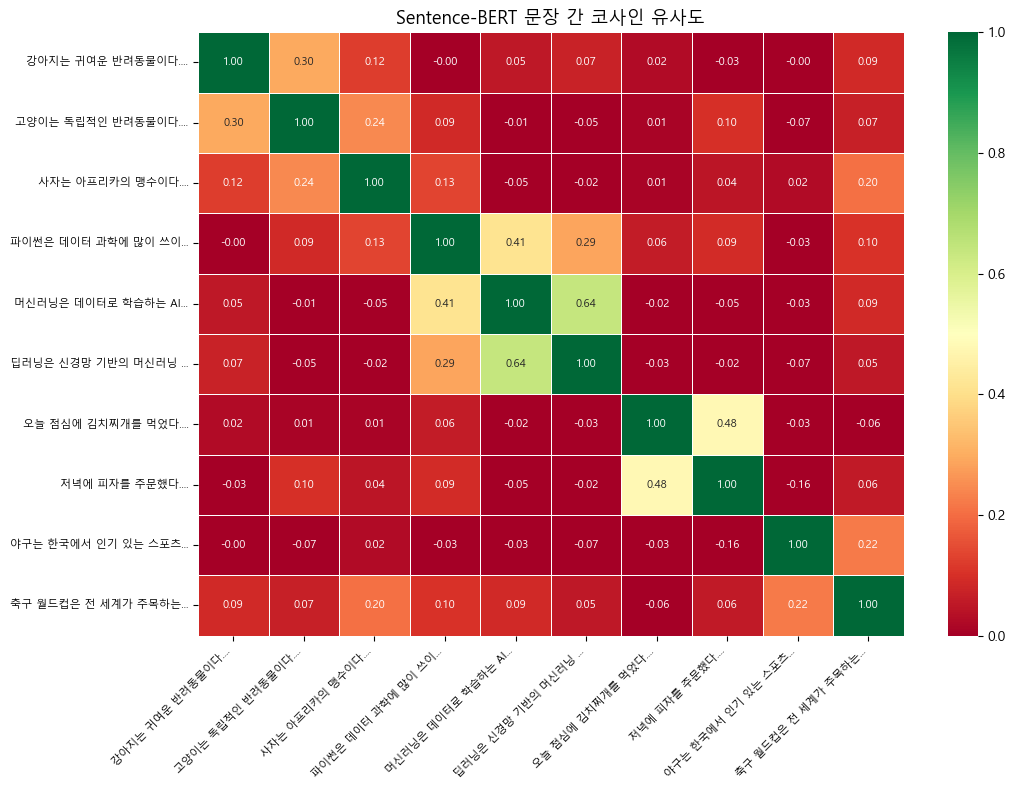

In [55]:
if SBERT_AVAILABLE:
    sentences = [
        "강아지는 귀여운 반려동물이다.",
        "고양이는 독립적인 반려동물이다.",
        "사자는 아프리카의 맹수이다.",
        "파이썬은 데이터 과학에 많이 쓰이는 언어이다.",
        "머신러닝은 데이터로 학습하는 AI 기술이다.",
        "딥러닝은 신경망 기반의 머신러닝 기법이다.",
        "오늘 점심에 김치찌개를 먹었다.",
        "저녁에 피자를 주문했다.",
        "야구는 한국에서 인기 있는 스포츠이다.",
        "축구 월드컵은 전 세계가 주목하는 대회이다.",
    ]
    labels_cat = ['동물', '동물', '동물', 'IT/AI', 'IT/AI', 'IT/AI',
                  '음식', '음식', '스포츠', '스포츠']

    embeddings = sbert.encode(sentences, show_progress_bar=True)
    print(f"\n임베딩 shape: {embeddings.shape}")

    sim_matrix = cos_sim(embeddings)

    # 히트맵
    short = [s[:18] + '...' for s in sentences]
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(sim_matrix, xticklabels=short, yticklabels=short,
                annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
    ax.set_title('Sentence-BERT 문장 간 코사인 유사도', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig('7_sbert_similarity.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5-4. Sentence-BERT 임베딩 t-SNE 시각화

In [56]:
if SBERT_AVAILABLE:
    tsne_s = TSNE(n_components=2, perplexity=3, random_state=42,
                  n_iter=2000, learning_rate='auto', init='pca')
    red_s = tsne_s.fit_transform(embeddings)

    cat_pal = {'동물': '#f87171', 'IT/AI': '#4f8ef7',
               '음식': '#a78bfa', '스포츠': '#fbbf24'}
    fig, ax = plt.subplots(figsize=(10, 7))
    for cat, color in cat_pal.items():
        idx = [i for i, l in enumerate(labels_cat) if l == cat]
        ax.scatter(red_s[idx, 0], red_s[idx, 1],
                   c=color, s=120, alpha=0.85, label=cat,
                   edgecolors='white', linewidth=0.5, zorder=5)

    for i, sent in enumerate(sentences):
        ax.annotate(sent[:15] + '...',
                    xy=(red_s[i, 0], red_s[i, 1]),
                    xytext=(5, 3), textcoords='offset points', fontsize=8)

    ax.set_title('Sentence-BERT t-SNE 시각화', fontsize=13)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('8_sbert_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

### 5-5. [도전] 간단한 시맨틱 검색

In [57]:
if SBERT_AVAILABLE:
    docs = [
        "파이썬으로 데이터를 시각화하는 방법.",
        "Pandas를 이용한 데이터프레임 조작.",
        "머신러닝 모델을 Scikit-learn으로 구현.",
        "딥러닝 CNN을 이용한 이미지 분류.",
        "자연어처리 BERT 모델 파인튜닝 가이드.",
        "Word2Vec과 FastText 임베딩 비교.",
        "t-SNE와 PCA를 이용한 고차원 시각화.",
        "데이터 전처리: 정규화와 인코딩.",
    ]
    doc_emb = sbert.encode(docs)

    def semantic_search(query, top_k=3):
        q_emb = sbert.encode([query])
        sims = cos_sim(q_emb, doc_emb)[0]
        top  = sims.argsort()[::-1][:top_k]
        print(f"\n🔍 쿼리: '{query}'")
        for rank, i in enumerate(top, 1):
            print(f"  [{rank}위] {sims[i]:.3f}  {docs[i]}")

    for q in ["시각화 라이브러리 사용법", "텍스트 임베딩 모델", "데이터 전처리 방법"]:
        semantic_search(q)


🔍 쿼리: '시각화 라이브러리 사용법'
  [1위] 0.746  파이썬으로 데이터를 시각화하는 방법.
  [2위] 0.540  t-SNE와 PCA를 이용한 고차원 시각화.
  [3위] 0.524  딥러닝 CNN을 이용한 이미지 분류.

🔍 쿼리: '텍스트 임베딩 모델'
  [1위] 0.702  Word2Vec과 FastText 임베딩 비교.
  [2위] 0.485  데이터 전처리: 정규화와 인코딩.
  [3위] 0.311  자연어처리 BERT 모델 파인튜닝 가이드.

🔍 쿼리: '데이터 전처리 방법'
  [1위] 0.776  데이터 전처리: 정규화와 인코딩.
  [2위] 0.640  파이썬으로 데이터를 시각화하는 방법.
  [3위] 0.496  Pandas를 이용한 데이터프레임 조작.


---
## 📊 Part 6. 종합 — 임베딩 모델 비교 레이더 차트

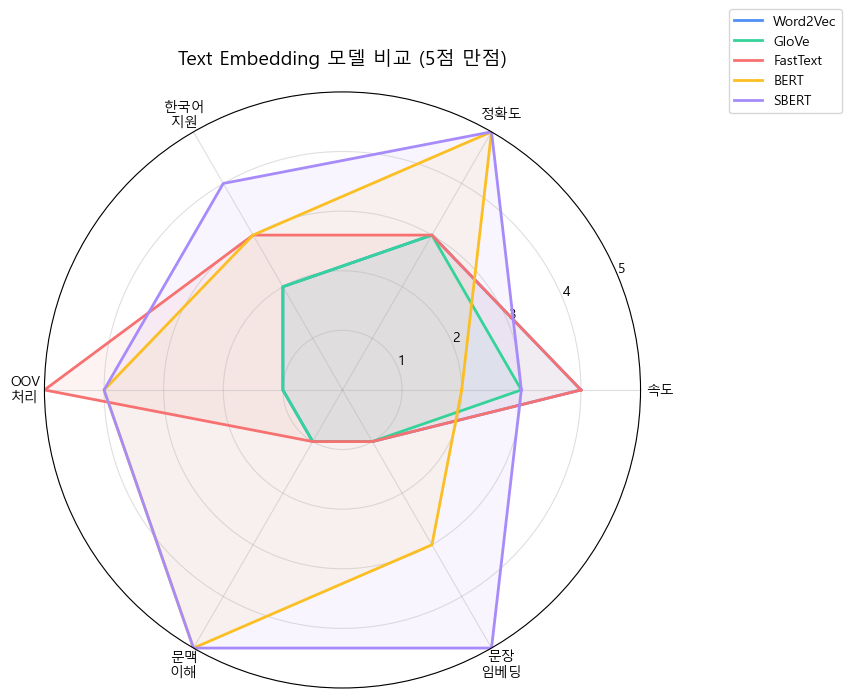

In [58]:
categories = ['속도', '정확도', '한국어\n지원', 'OOV\n처리', '문맥\n이해', '문장\n임베딩']
N = len(categories)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

models = {
    'Word2Vec': [4, 3, 2, 1, 1, 1],
    'GloVe':    [3, 3, 2, 1, 1, 1],
    'FastText': [4, 3, 3, 5, 1, 1],
    'BERT':     [2, 5, 3, 4, 5, 3],
    'SBERT':    [3, 5, 4, 4, 5, 5],
}
r_colors = ['#4f8ef7', '#34d399', '#f87171', '#fbbf24', '#a78bfa']

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
for (name, scores), color in zip(models.items(), r_colors):
    vals = scores + scores[:1]
    ax.plot(angles, vals, lw=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 5)
ax.set_title('Text Embedding 모델 비교 (5점 만점)', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('9_embedding_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ 마무리 정리

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║                   4주차 실습 핵심 요약                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 시각화                                                   ║
║    • Matplotlib: Figure / Axes 계층 구조                     ║
║    • Seaborn: 통계 시각화, DataFrame 직접 연동               ║
║    • 한국어 폰트: rcParams 설정 필수                         ║
║                                                              ║
║  📐 수치형 전처리                                            ║
║    • Min-Max 정규화 → [0, 1]  (이상치에 민감)               ║
║    • Z-score 표준화 → (μ=0, σ=1)  (이상치에 강건)           ║
║    • fit()은 훈련 데이터에만! 테스트는 transform()만 사용    ║
║                                                              ║
║  🏷️ 범주형 전처리                                            ║
║    • Label Encoding: 순서 있는 범주 (학점, 등급)             ║
║    • One-Hot Encoding: 순서 없는 범주 (색상, 도시)           ║
║    • drop_first=True 로 더미 함정(다중공선성) 방지           ║
║                                                              ║
║  🧠 Text Embedding                                           ║
║    • One-Hot 한계 → 밀집 벡터로 의미 표현                    ║
║    • Word2Vec / FastText: 단어 수준 임베딩                   ║
║    • BERT / SBERT: 문맥 이해, 문장 수준 임베딩               ║
║    • t-SNE: 고차원 임베딩 → 2D 시각화                        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")